# 균일 HSBM n 변화 - Zhou theta 비랜덤 실험

이 노트북은 균일 HSBM 하이퍼그래프를 생성하고, Zhou normalized hypergraph Laplacian에서 만든 `Theta = I - Delta`로 spectral clustering을 수행한다.

`n`이 커질 때 오분류율, ARI, NMI, CPU 시간, wall-clock 시간, 메모리, 알고리즘 단계별 시간을 기록한다.


In [1]:
from pathlib import Path
import gc
import json
import sys
import time
import tracemalloc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "common.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root containing src/common.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import (
    generate_planted_uniform_hsbm_instance,
    normalize_rows_l2,
    zhou_normalized_laplacian,
)

EXPERIMENT_ID = "EXP-20260426-004"
EXPERIMENT_SLUG = "uniform_hsbm_n_scaling_zhou_laplacian"
OUTDIR = PROJECT_ROOT / "experiments" / "\uade0\uc77c HSBM \uc2e4\ud5d8" / "results" / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}"
OUTDIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

EXPERIMENT_ID, EXPERIMENT_SLUG, PROJECT_ROOT, OUTDIR

('EXP-20260426-004',
 'uniform_hsbm_n_scaling_zhou_laplacian',
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian'))

## 설정

`a_in`, `b_out`, `rho_n`은 `p_in = a_in * rho_n / n ** (m - 1)`, `p_out = b_out * rho_n / n ** (m - 1)`로 변환한다.


In [2]:
CONFIG = {
    "K": 3,
    "m": 3,
    "a_in": 36.0,
    "b_out": 4.0,
    "rho_n": 4.0,
    "reps": 10,
    "seed": 20260426,
    "sampling": "sparse",
    "max_enumeration": 1_500_000,
    "normalize_embedding_rows": True,
    "eigsh_tol": 1e-6,
}

N_VALUES = list(range(1000, 10001, 1000))

CONFIG, N_VALUES

({'K': 3,
  'm': 3,
  'a_in': 36.0,
  'b_out': 4.0,
  'rho_n': 4.0,
  'reps': 10,
  'seed': 20260426,
  'sampling': 'sparse',
  'max_enumeration': 1500000,
  'normalize_embedding_rows': True,
  'eigsh_tol': 1e-06},
 [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000])

## 보조 함수


In [3]:
def current_rss_mb():
    try:
        import psutil

        return psutil.Process().memory_info().rss / (1024.0 ** 2)
    except Exception:
        return np.nan


def measure_call(fn):
    gc.collect()
    rss_before_mb = current_rss_mb()
    tracemalloc.start()
    cpu_start = time.process_time()
    wall_start = time.perf_counter()
    value = fn()
    wall_clock_sec = time.perf_counter() - wall_start
    cpu_time_sec = time.process_time() - cpu_start
    current_bytes, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after_mb = current_rss_mb()
    return value, {
        "cpu_time_sec": float(cpu_time_sec),
        "wall_clock_sec": float(wall_clock_sec),
        "peak_traced_memory_mb": float(peak_bytes / (1024.0 ** 2)),
        "rss_before_mb": float(rss_before_mb) if np.isfinite(rss_before_mb) else np.nan,
        "rss_after_mb": float(rss_after_mb) if np.isfinite(rss_after_mb) else np.nan,
        "rss_delta_mb": float(rss_after_mb - rss_before_mb)
        if np.isfinite(rss_before_mb) and np.isfinite(rss_after_mb)
        else np.nan,
    }


def aligned_misclassification_rate(y_true, y_pred, K):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    conf = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < K and 0 <= p < K:
            conf[t, p] += 1
    true_ids, pred_ids = linear_sum_assignment(-conf)
    pred_to_true = {int(pred): int(true) for true, pred in zip(true_ids, pred_ids)}
    y_aligned = np.array([pred_to_true.get(int(p), int(p)) for p in y_pred], dtype=int)
    return float(np.mean(y_aligned != y_true)), y_aligned, conf


def hypergraph_vertex_degree_stats(n, hyperedges):
    degrees = np.zeros(int(n), dtype=float)
    for edge in hyperedges:
        for v in edge:
            degrees[int(v)] += 1.0
    return {
        "num_isolated_nodes": int(np.sum(degrees == 0)),
        "hypergraph_degree_mean": float(degrees.mean()) if n > 0 else 0.0,
        "hypergraph_degree_max": float(degrees.max()) if n > 0 else 0.0,
    }


def spectral_cluster_from_zhou_theta(theta, K, rng, normalize_rows=True, eigsh_tol=1e-6):
    n = int(theta.shape[0])
    theta = ((theta + theta.T) * 0.5).tocsr()
    total_start = time.perf_counter()
    timings = {}

    t0 = time.perf_counter()
    try:
        if n <= K + 1:
            vals, vecs = np.linalg.eigh(theta.toarray())
        else:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                vals, vecs = spla.eigsh(
                    theta,
                    k=K,
                    which="LA",
                    tol=float(eigsh_tol),
                    v0=rng.normal(size=n),
                )
    except Exception:
        vals, vecs = np.linalg.eigh(theta.toarray())
    order = np.argsort(vals)[-K:][::-1]
    top_vals = vals[order]
    top_vecs = vecs[:, order]
    U = top_vecs
    timings["eigen_decomposition_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    if normalize_rows:
        U = normalize_rows_l2(U)
    timings["embedding_normalize_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_state = int(rng.integers(1, 2**31 - 1))
    labels = KMeans(n_clusters=K, n_init=20, random_state=random_state).fit_predict(U)
    timings["kmeans_wall_sec"] = time.perf_counter() - t0
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - total_start
    return labels, {
        "zhou_theta_nnz": int(theta.nnz),
        **timings,
    }


def run_one_rep(n, rep, config):
    K = int(config["K"])
    m = int(config["m"])
    seed = int(config["seed"] + 1_000_003 * int(n) + int(rep))
    rng = np.random.default_rng(seed)
    timings = {}
    t0 = time.perf_counter()
    hyperedges, y_true, Theta_true, gen_stats = generate_planted_uniform_hsbm_instance(
        n=n,
        K=K,
        d=m,
        a_d=float(config["a_in"]),
        b_d=float(config["b_out"]),
        rho_n=float(config["rho_n"]),
        rng=rng,
        sampling=config["sampling"],
        max_enumeration=int(config["max_enumeration"]),
        clip=False,
    )
    p_in = float(gen_stats["p_in"])
    p_out = float(gen_stats["p_out"])
    timings["generation_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    L = zhou_normalized_laplacian(n=n, hyperedges=hyperedges)
    theta = (sp.eye(n, format="csr", dtype=float) - L).tocsr()
    theta.eliminate_zeros()
    timings["zhou_laplacian_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred, spectral_stats = spectral_cluster_from_zhou_theta(
        theta=theta,
        K=K,
        rng=rng,
        normalize_rows=bool(config["normalize_embedding_rows"]),
        eigsh_tol=float(config["eigsh_tol"]),
    )
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    mis, y_aligned, conf = aligned_misclassification_rate(y_true, y_pred, K)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    timings["metric_wall_sec"] = time.perf_counter() - t0

    record = {
        "n": int(n),
        "rep": int(rep),
        "seed": seed,
        "K": K,
        "m": m,
        "num_hyperedges_total": int(len(hyperedges)),
        "misclassification_rate": mis,
        "ARI": float(ari),
        "NMI": float(nmi),
        **timings,
        **hypergraph_vertex_degree_stats(n, hyperedges),
        **spectral_stats,
    }
    record["algorithm_total_wall_sec"] = float(
        record["generation_wall_sec"]
        + record["zhou_laplacian_wall_sec"]
        + record["eigen_decomposition_wall_sec"]
        + record["embedding_normalize_wall_sec"]
        + record["kmeans_wall_sec"]
    )
    record["rho_n"] = float(config["rho_n"])
    record["p_in"] = float(p_in)
    record["p_out"] = float(p_out)
    record["sampling_mode"] = gen_stats.get("sampling_mode", "")
    return record


def run_one_rep_measured(n, rep, config):
    record, measurement = measure_call(lambda: run_one_rep(n, rep, config))
    record.update(measurement)
    return record


def run_n_experiment(n, reps=None, config=None):
    if config is None:
        config = CONFIG
    if reps is None:
        reps = int(config["reps"])

    rows = []
    for rep in range(1, reps + 1):
        row = run_one_rep_measured(n=n, rep=rep, config=config)
        rows.append(row)
        print(
            f"n={n:5d} rep={rep:2d}/{reps:<2d} "
            f"edges={row['num_hyperedges_total']:6d} "
            f"mis={row['misclassification_rate']:.4f} "
            f"ARI={row['ARI']:.4f} NMI={row['NMI']:.4f} "
            f"eig={row['eigen_decomposition_wall_sec']:.3f}s "
            f"km={row['kmeans_wall_sec']:.3f}s "
            f"wall={row['wall_clock_sec']:.3f}s "
            f"peak={row['peak_traced_memory_mb']:.1f}MB"
        )

    df = pd.DataFrame(rows)
    display(df)
    return df


def summarize_by_n(df_raw):
    return df_raw.groupby("n", as_index=False).agg(
        reps=("rep", "count"),
        hyperedges_mean=("num_hyperedges_total", "mean"),
        hyperedges_std=("num_hyperedges_total", "std"),
        misclassification_mean=("misclassification_rate", "mean"),
        misclassification_std=("misclassification_rate", "std"),
        ari_mean=("ARI", "mean"),
        ari_std=("ARI", "std"),
        nmi_mean=("NMI", "mean"),
        nmi_std=("NMI", "std"),
        generation_wall_sec_mean=("generation_wall_sec", "mean"),
        generation_wall_sec_std=("generation_wall_sec", "std"),
        zhou_laplacian_wall_sec_mean=("zhou_laplacian_wall_sec", "mean"),
        zhou_laplacian_wall_sec_std=("zhou_laplacian_wall_sec", "std"),
        eigen_decomposition_wall_sec_mean=("eigen_decomposition_wall_sec", "mean"),
        eigen_decomposition_wall_sec_std=("eigen_decomposition_wall_sec", "std"),
        embedding_normalize_wall_sec_mean=("embedding_normalize_wall_sec", "mean"),
        embedding_normalize_wall_sec_std=("embedding_normalize_wall_sec", "std"),
        kmeans_wall_sec_mean=("kmeans_wall_sec", "mean"),
        kmeans_wall_sec_std=("kmeans_wall_sec", "std"),
        spectral_clustering_wall_sec_mean=("spectral_clustering_wall_sec", "mean"),
        spectral_clustering_wall_sec_std=("spectral_clustering_wall_sec", "std"),
        metric_wall_sec_mean=("metric_wall_sec", "mean"),
        metric_wall_sec_std=("metric_wall_sec", "std"),
        algorithm_total_wall_sec_mean=("algorithm_total_wall_sec", "mean"),
        algorithm_total_wall_sec_std=("algorithm_total_wall_sec", "std"),
        cpu_time_sec_mean=("cpu_time_sec", "mean"),
        cpu_time_sec_std=("cpu_time_sec", "std"),
        wall_clock_sec_mean=("wall_clock_sec", "mean"),
        wall_clock_sec_std=("wall_clock_sec", "std"),
        peak_traced_memory_mb_mean=("peak_traced_memory_mb", "mean"),
        peak_traced_memory_mb_std=("peak_traced_memory_mb", "std"),
        rss_delta_mb_mean=("rss_delta_mb", "mean"),
        rss_delta_mb_std=("rss_delta_mb", "std"),
    )

## n = 1000


In [4]:
df_n1000 = run_n_experiment(1000)

n= 1000 rep= 1/10 edges=  5028 mis=0.0230 ARI=0.9319 NMI=0.8926 eig=0.002s km=0.216s wall=0.420s peak=2.5MB


n= 1000 rep= 2/10 edges=  4841 mis=0.0160 ARI=0.9526 NMI=0.9200 eig=0.002s km=0.039s wall=0.255s peak=2.4MB


n= 1000 rep= 3/10 edges=  5101 mis=0.0200 ARI=0.9408 NMI=0.9012 eig=0.002s km=0.040s wall=0.271s peak=2.5MB


n= 1000 rep= 4/10 edges=  4913 mis=0.0170 ARI=0.9495 NMI=0.9126 eig=0.002s km=0.043s wall=0.266s peak=2.5MB


n= 1000 rep= 5/10 edges=  4986 mis=0.0130 ARI=0.9613 NMI=0.9293 eig=0.002s km=0.037s wall=0.315s peak=2.5MB


...

n= 1000 rep= 7/10 edges=  5164 mis=0.0140 ARI=0.9584 NMI=0.9252 eig=0.002s km=0.041s wall=0.296s peak=2.6MB


n= 1000 rep= 8/10 edges=  5102 mis=0.0180 ARI=0.9467 NMI=0.9083 eig=0.002s km=0.040s wall=0.324s peak=2.5MB


n= 1000 rep= 9/10 edges=  5131 mis=0.0120 ARI=0.9643 NMI=0.9350 eig=0.002s km=0.037s wall=0.287s peak=2.6MB


n= 1000 rep=10/10 edges=  4934 mis=0.0160 ARI=0.9525 NMI=0.9163 eig=0.002s km=0.037s wall=0.266s peak=2.5MB


,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,1000,1,1020263427,3,3,5028,0.023,0.931926,0.892609,0.160638,0.013345,0.218428,0.006637,0,15.084,26.0,30538,0.001964,0.000042,0.216415,0.392404,4.0,0.000144,0.000016,sparse,1.620934,0.420445,2.533346,260.921875,265.343750,4.421875
1,1000,2,1020263428,3,3,4841,0.016,0.952566,0.920037,0.177809,0.012231,0.041207,0.006631,0,14.523,28.0,29398,0.001954,0.000046,0.039203,0.231243,4.0,0.000144,0.000016,sparse,1.691108,0.255374,2.425808,265.343750,267.187500,1.843750
2,1000,3,1020263429,3,3,5101,0.020,0.940775,0.901199,0.188685,0.013140,0.041704,0.008083,0,15.303,29.0,30874,0.002014,0.000042,0.039644,0.243524,4.0,0.000144,0.000016,sparse,1.932465,0.270501,2.547312,267.187500,268.234375,1.046875
3,1000,4,1020263430,3,3,4913,0.017,0.949532,0.912641,0.184732,0.012706,0.045170,0.006097,0,14.739,27.0,29776,0.001948,0.000045,0.043173,0.242604,4.0,0.000144,0.000016,sparse,1.823412,0.266221,2.457828,268.234375,268.609375,0.375000
4,1000,5,1020263431,3,3,4986,0.013,0.961309,0.929286,0.228235,0.014401,0.039109,0.008847,0,14.958,28.0,30304,0.002059,0.000051,0.036996,0.281742,4.0,0.000144,0.000016,sparse,1.462339,0.314929,2.497471,268.609375,268.765625,0.156250
5,1000,6,1020263432,3,3,5085,0.017,0.949524,0.915557,0.202856,0.013309,0.040837,0.008619,0,15.255,30.0,30830,0.002047,0.000040,0.038747,0.256999,4.0,0.000144,0.000016,sparse,1.801635,0.283529,2.544127,268.765625,269.125000,0.359375
6,1000,7,1020263433,3,3,5164,0.014,0.958400,0.925156,0.212558,0.013296,0.043328,0.007912,0,15.492,30.0,31320,0.001917,0.000037,0.041369,0.269178,4.0,0.000144,0.000016,sparse,1.811747,0.295605,2.580536,269.125000,269.437500,0.312500
7,1000,8,1020263434,3,3,5102,0.018,0.946668,0.908279,0.243890,0.015096,0.042674,0.005282,0,15.306,31.0,30918,0.002268,0.000093,0.040308,0.301655,4.0,0.000144,0.000016,sparse,1.668491,0.324269,2.548819,269.437500,269.484375,0.046875
8,1000,9,1020263435,3,3,5131,0.012,0.964298,0.935002,0.207336,0.013136,0.039084,0.006183,0,15.393,27.0,31130,0.001882,0.000039,0.037160,0.259552,4.0,0.000144,0.000016,sparse,1.912157,0.286782,2.565180,269.484375,270.046875,0.562500
9,1000,10,1020263436,3,3,4934,0.016,0.952484,0.916252,0.194104,0.012769,0.038946,0.005062,0,14.802,28.0,29986,0.001901,0.000038,0.037004,0.245816,4.0,0.000144,0.000016,sparse,1.888438,0.266080,2.469722,270.046875,270.046875,0.000000


## n = 2000


In [5]:
df_n2000 = run_n_experiment(2000)

n= 2000 rep= 1/10 edges= 10073 mis=0.0180 ARI=0.9467 NMI=0.9072 eig=0.004s km=0.062s wall=0.561s peak=5.2MB


n= 2000 rep= 2/10 edges= 10034 mis=0.0185 ARI=0.9453 NMI=0.9057 eig=0.003s km=0.057s wall=0.563s peak=5.2MB


n= 2000 rep= 3/10 edges= 10121 mis=0.0195 ARI=0.9424 NMI=0.9020 eig=0.003s km=0.060s wall=0.560s peak=5.2MB


n= 2000 rep= 4/10 edges= 10056 mis=0.0170 ARI=0.9496 NMI=0.9123 eig=0.003s km=0.062s wall=0.529s peak=5.2MB


n= 2000 rep= 5/10 edges= 10120 mis=0.0195 ARI=0.9423 NMI=0.9007 eig=0.003s km=0.052s wall=0.480s peak=5.2MB


...

n= 2000 rep= 7/10 edges=  9950 mis=0.0190 ARI=0.9438 NMI=0.9036 eig=0.003s km=0.048s wall=0.518s peak=5.1MB


n= 2000 rep= 8/10 edges= 10077 mis=0.0195 ARI=0.9424 NMI=0.9032 eig=0.003s km=0.064s wall=0.534s peak=5.2MB


n= 2000 rep= 9/10 edges= 10043 mis=0.0175 ARI=0.9482 NMI=0.9107 eig=0.003s km=0.056s wall=0.513s peak=5.2MB


n= 2000 rep=10/10 edges= 10180 mis=0.0145 ARI=0.9570 NMI=0.9236 eig=0.003s km=0.050s wall=0.518s peak=5.2MB


,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,2000,1,2020266427,3,3,10073,0.0180,0.946672,0.907246,0.407902,0.029784,0.065696,0.013410,0,15.1095,29.0,61814,0.003969,0.000064,0.061658,0.503377,4.0,0.000036,0.000004,sparse,2.010588,0.560906,5.183298,270.421875,274.500000,4.078125
1,2000,2,2020266428,3,3,10034,0.0185,0.945267,0.905656,0.427796,0.022590,0.060097,0.011031,0,15.0510,30.0,61550,0.003160,0.000045,0.056889,0.510479,4.0,0.000036,0.000004,sparse,2.035642,0.563347,5.162408,274.500000,277.843750,3.343750
2,2000,3,2020266429,3,3,10121,0.0195,0.942353,0.901984,0.415394,0.027529,0.062700,0.013264,0,15.1815,29.0,62020,0.003000,0.000050,0.059647,0.505619,4.0,0.000036,0.000004,sparse,1.956693,0.559521,5.199865,277.843750,278.875000,1.031250
3,2000,4,2020266430,3,3,10056,0.0170,0.949644,0.912324,0.395411,0.023166,0.065174,0.010062,0,15.0840,32.0,61714,0.002992,0.000139,0.062036,0.483744,4.0,0.000036,0.000004,sparse,1.898958,0.528612,5.177273,278.875000,279.734375,0.859375
4,2000,5,2020266431,3,3,10120,0.0195,0.942315,0.900739,0.363866,0.022574,0.054850,0.007801,0,15.1800,29.0,62082,0.002846,0.000042,0.051960,0.441287,4.0,0.000036,0.000004,sparse,1.943133,0.480149,5.205715,279.734375,280.703125,0.968750
5,2000,6,2020266432,3,3,10014,0.0135,0.959910,0.928045,0.377321,0.024648,0.071687,0.013032,0,15.0210,29.0,61458,0.003494,0.000054,0.068133,0.473650,4.0,0.000036,0.000004,sparse,2.353647,0.545836,5.158167,280.703125,277.625000,-3.078125
6,2000,7,2020266433,3,3,9950,0.0190,0.943783,0.903638,0.392309,0.028565,0.050664,0.009439,0,14.9250,28.0,61038,0.002946,0.000049,0.047664,0.471533,4.0,0.000036,0.000004,sparse,1.444879,0.517825,5.123735,270.781250,250.578125,-20.203125
7,2000,8,2020266434,3,3,10077,0.0195,0.942352,0.903165,0.396665,0.023240,0.067345,0.011289,0,15.1155,29.0,61842,0.002913,0.000045,0.064383,0.487247,4.0,0.000036,0.000004,sparse,2.175855,0.534262,5.185945,250.578125,252.046875,1.468750
8,2000,9,2020266435,3,3,10043,0.0175,0.948180,0.910675,0.380114,0.022152,0.059278,0.010314,0,15.0645,30.0,61664,0.003316,0.000051,0.055907,0.461540,4.0,0.000036,0.000004,sparse,1.989228,0.512958,5.172070,252.046875,251.265625,-0.781250
9,2000,10,2020266436,3,3,10180,0.0145,0.956967,0.923569,0.389909,0.025094,0.053212,0.011220,0,15.2700,29.0,62414,0.002943,0.000047,0.050218,0.468212,4.0,0.000036,0.000004,sparse,2.026453,0.518210,5.234709,251.265625,250.984375,-0.281250


## n = 3000


In [6]:
df_n3000 = run_n_experiment(3000)

n= 3000 rep= 1/10 edges= 15110 mis=0.0177 ARI=0.9477 NMI=0.9081 eig=0.004s km=0.077s wall=0.709s peak=7.8MB


n= 3000 rep= 2/10 edges= 15089 mis=0.0123 ARI=0.9633 NMI=0.9320 eig=0.004s km=0.066s wall=0.711s peak=7.8MB


n= 3000 rep= 3/10 edges= 15205 mis=0.0137 ARI=0.9594 NMI=0.9265 eig=0.004s km=0.066s wall=0.739s peak=7.9MB


n= 3000 rep= 4/10 edges= 15357 mis=0.0127 ARI=0.9623 NMI=0.9308 eig=0.004s km=0.077s wall=0.727s peak=8.0MB


n= 3000 rep= 5/10 edges= 15167 mis=0.0220 ARI=0.9351 NMI=0.8911 eig=0.004s km=0.068s wall=0.763s peak=7.9MB


...

n= 3000 rep= 7/10 edges= 15008 mis=0.0170 ARI=0.9496 NMI=0.9111 eig=0.004s km=0.094s wall=0.736s peak=7.8MB


n= 3000 rep= 8/10 edges= 15233 mis=0.0133 ARI=0.9604 NMI=0.9283 eig=0.004s km=0.092s wall=0.726s peak=7.9MB


n= 3000 rep= 9/10 edges= 15169 mis=0.0120 ARI=0.9643 NMI=0.9337 eig=0.004s km=0.075s wall=0.735s peak=7.9MB


n= 3000 rep=10/10 edges= 15125 mis=0.0167 ARI=0.9506 NMI=0.9139 eig=0.004s km=0.057s wall=0.730s peak=7.9MB


,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,3000,1,3020269427,3,3,15110,0.017667,0.947670,0.908094,0.525175,0.034531,0.081538,0.012984,0,15.110,29.0,93020,0.004083,0.000096,0.077356,0.641240,4.0,0.000016,0.000002,sparse,2.565101,0.708855,7.844739,250.984375,254.515625,3.531250
1,3000,2,3020269428,3,3,15089,0.012333,0.963321,0.932013,0.529233,0.034235,0.069726,0.014855,0,15.089,30.0,92890,0.003798,0.000055,0.065870,0.633190,4.0,0.000016,0.000002,sparse,2.376376,0.711125,7.832448,254.515625,261.140625,6.625000
2,3000,3,3020269429,3,3,15205,0.013667,0.959411,0.926522,0.566927,0.036303,0.070307,0.011986,0,15.205,31.0,93556,0.003901,0.000050,0.066353,0.673534,4.0,0.000016,0.000002,sparse,2.343674,0.739036,7.891073,261.140625,262.953125,1.812500
3,3000,4,3020269430,3,3,15357,0.012667,0.962344,0.930781,0.545311,0.033487,0.080821,0.013697,0,15.357,31.0,94456,0.003730,0.000048,0.077040,0.659617,4.0,0.000016,0.000002,sparse,2.514510,0.726597,7.967155,262.953125,266.406250,3.453125
4,3000,5,3020269431,3,3,15167,0.022000,0.935081,0.891050,0.575749,0.035275,0.072506,0.017720,0,15.167,31.0,93316,0.004185,0.000052,0.068264,0.683526,4.0,0.000016,0.000002,sparse,2.465906,0.763178,7.869509,266.406250,266.531250,0.125000
5,3000,6,3020269432,3,3,15114,0.016000,0.952552,0.915744,0.564829,0.036745,0.073215,0.011979,0,15.114,31.0,93034,0.003912,0.000063,0.069237,0.674786,4.0,0.000016,0.000002,sparse,2.321342,0.741111,7.845231,266.531250,270.515625,3.984375
6,3000,7,3020269433,3,3,15008,0.017000,0.949626,0.911098,0.536615,0.034932,0.098312,0.014478,0,15.008,31.0,92370,0.004041,0.000099,0.094168,0.669854,4.0,0.000016,0.000002,sparse,2.614188,0.735523,7.791027,270.375000,272.031250,1.656250
7,3000,8,3020269434,3,3,15233,0.013333,0.960396,0.928338,0.525272,0.033561,0.096257,0.012755,0,15.233,30.0,93792,0.003755,0.000047,0.092452,0.655087,4.0,0.000016,0.000002,sparse,2.664906,0.725858,7.909402,272.031250,272.656250,0.625000
8,3000,9,3020269435,3,3,15169,0.012000,0.964310,0.933712,0.548190,0.032364,0.078765,0.014041,0,15.169,31.0,93346,0.003847,0.000048,0.074867,0.659315,4.0,0.000016,0.000002,sparse,2.542645,0.735242,7.872469,272.656250,272.984375,0.328125
9,3000,10,3020269436,3,3,15125,0.016667,0.950635,0.913920,0.561654,0.035562,0.061419,0.014366,0,15.125,34.0,93102,0.004168,0.000054,0.057194,0.658632,4.0,0.000016,0.000002,sparse,2.222395,0.729594,7.855271,272.984375,272.859375,-0.125000


## n = 4000


In [7]:
df_n4000 = run_n_experiment(4000)

n= 4000 rep= 1/10 edges= 20134 mis=0.0230 ARI=0.9322 NMI=0.8873 eig=0.005s km=0.079s wall=0.913s peak=10.5MB


n= 4000 rep= 2/10 edges= 20403 mis=0.0192 ARI=0.9431 NMI=0.9019 eig=0.005s km=0.077s wall=0.964s peak=10.6MB


n= 4000 rep= 3/10 edges= 20027 mis=0.0140 ARI=0.9584 NMI=0.9247 eig=0.005s km=0.067s wall=0.930s peak=10.4MB


n= 4000 rep= 4/10 edges= 20146 mis=0.0165 ARI=0.9511 NMI=0.9133 eig=0.005s km=0.072s wall=0.921s peak=10.5MB


n= 4000 rep= 5/10 edges= 20006 mis=0.0143 ARI=0.9577 NMI=0.9243 eig=0.005s km=0.071s wall=0.971s peak=10.4MB


...

n= 4000 rep= 7/10 edges= 20091 mis=0.0182 ARI=0.9460 NMI=0.9056 eig=0.005s km=0.062s wall=0.878s peak=10.5MB


n= 4000 rep= 8/10 edges= 20286 mis=0.0163 ARI=0.9518 NMI=0.9146 eig=0.005s km=0.072s wall=0.949s peak=10.6MB


n= 4000 rep= 9/10 edges= 20053 mis=0.0190 ARI=0.9438 NMI=0.9038 eig=0.005s km=0.068s wall=0.919s peak=10.5MB


n= 4000 rep=10/10 edges= 20146 mis=0.0173 ARI=0.9489 NMI=0.9106 eig=0.005s km=0.077s wall=0.938s peak=10.5MB


,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,4000,1,4020272427,3,3,20134,0.02300,0.932215,0.887314,0.682836,0.044738,0.083476,0.018344,0,15.10050,31.0,124190,0.004751,0.000056,0.078666,0.811047,4.0,0.000009,0.000001,sparse,2.809031,0.912801,10.502268,272.859375,275.312500,2.453125
1,4000,2,4020272428,3,3,20403,0.01925,0.943055,0.901932,0.738553,0.043682,0.081537,0.019183,0,15.30225,30.0,125716,0.004661,0.000082,0.076791,0.863769,4.0,0.000009,0.000001,sparse,2.584722,0.963646,10.630270,275.312500,279.203125,3.890625
2,4000,3,4020272429,3,3,20027,0.01400,0.958435,0.924731,0.720596,0.042932,0.072199,0.015000,0,15.02025,31.0,123464,0.005039,0.000057,0.067099,0.835724,4.0,0.000009,0.000001,sparse,2.585218,0.929606,10.445639,279.203125,280.953125,1.750000
3,4000,4,4020272430,3,3,20146,0.01650,0.951089,0.913307,0.710865,0.042766,0.077012,0.018477,0,15.10950,32.0,124230,0.004797,0.000057,0.072152,0.830638,4.0,0.000009,0.000001,sparse,2.665609,0.920546,10.510644,280.953125,281.734375,0.781250
4,4000,5,4020272431,3,3,20006,0.01425,0.957695,0.924259,0.746752,0.043823,0.076288,0.016520,0,15.00450,29.0,123342,0.005022,0.000061,0.071202,0.866858,4.0,0.000009,0.000001,sparse,2.731512,0.970913,10.437543,281.734375,282.218750,0.484375
5,4000,6,4020272432,3,3,20189,0.02225,0.934334,0.889765,0.723768,0.043396,0.097348,0.021563,0,15.14175,31.0,124464,0.005105,0.000067,0.092170,0.864507,4.0,0.000009,0.000001,sparse,2.842028,0.968135,10.526078,282.218750,282.375000,0.156250
6,4000,7,4020272433,3,3,20091,0.01825,0.945972,0.905585,0.681405,0.042207,0.067169,0.019594,0,15.06825,35.0,123956,0.004716,0.000059,0.062391,0.790778,4.0,0.000009,0.000001,sparse,2.346877,0.877746,10.483492,282.375000,283.953125,1.578125
7,4000,8,4020272434,3,3,20286,0.01625,0.951827,0.914604,0.733925,0.043086,0.076680,0.017742,0,15.21450,30.0,125104,0.004791,0.000053,0.071833,0.853687,4.0,0.000009,0.000001,sparse,2.842422,0.948882,10.578358,283.953125,283.984375,0.031250
8,4000,9,4020272435,3,3,20053,0.01900,0.943785,0.903755,0.706980,0.046270,0.073372,0.017207,0,15.03975,30.0,123678,0.005115,0.000063,0.068190,0.826617,4.0,0.000009,0.000001,sparse,2.517342,0.918962,10.462378,283.984375,284.609375,0.625000
9,4000,10,4020272436,3,3,20146,0.01725,0.948894,0.910635,0.712731,0.042338,0.082319,0.014923,0,15.10950,31.0,124172,0.004925,0.000203,0.077186,0.837383,4.0,0.000009,0.000001,sparse,2.752968,0.938006,10.504568,284.609375,287.171875,2.562500


## n = 5000


In [8]:
df_n5000 = run_n_experiment(5000)

n= 5000 rep= 1/10 edges= 25130 mis=0.0180 ARI=0.9467 NMI=0.9068 eig=0.006s km=0.080s wall=1.059s peak=13.1MB


n= 5000 rep= 2/10 edges= 25223 mis=0.0178 ARI=0.9473 NMI=0.9078 eig=0.007s km=0.103s wall=1.252s peak=13.2MB


n= 5000 rep= 3/10 edges= 25161 mis=0.0168 ARI=0.9502 NMI=0.9129 eig=0.007s km=0.094s wall=1.290s peak=13.2MB


n= 5000 rep= 4/10 edges= 25115 mis=0.0184 ARI=0.9456 NMI=0.9054 eig=0.007s km=0.082s wall=1.307s peak=13.1MB


n= 5000 rep= 5/10 edges= 25001 mis=0.0186 ARI=0.9450 NMI=0.9048 eig=0.007s km=0.075s wall=1.197s peak=13.1MB


...

n= 5000 rep= 7/10 edges= 25025 mis=0.0140 ARI=0.9584 NMI=0.9245 eig=0.006s km=0.076s wall=1.156s peak=13.1MB


n= 5000 rep= 8/10 edges= 24981 mis=0.0170 ARI=0.9496 NMI=0.9111 eig=0.006s km=0.076s wall=1.144s peak=13.1MB


n= 5000 rep= 9/10 edges= 25116 mis=0.0154 ARI=0.9543 NMI=0.9185 eig=0.006s km=0.093s wall=1.143s peak=13.1MB


n= 5000 rep=10/10 edges= 24918 mis=0.0238 ARI=0.9298 NMI=0.8830 eig=0.006s km=0.117s wall=1.195s peak=13.0MB


,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,1,5020275427,3,3,25130,0.0180,0.946716,0.906828,0.805327,0.055364,0.086322,0.022320,0,15.0780,32.0,155120,0.005776,0.000149,0.080393,0.947009,4.0,0.000006,6.400000e-07,sparse,2.787024,1.059133,13.140502,287.171875,288.296875,1.125000
1,5000,2,5020275428,3,3,25223,0.0178,0.947304,0.907816,0.942439,0.061715,0.109554,0.024858,0,15.1338,32.0,155644,0.006691,0.000095,0.102762,1.113702,4.0,0.000006,6.400000e-07,sparse,3.139431,1.251733,13.183037,288.296875,288.578125,0.281250
2,5000,3,5020275429,3,3,25161,0.0168,0.950239,0.912852,0.946479,0.060866,0.101482,0.027833,0,15.0966,30.0,155348,0.007416,0.000084,0.093977,1.108821,4.0,0.000006,6.400000e-07,sparse,2.670340,1.289792,13.160722,272.703125,271.593750,-1.109375
3,5000,4,5020275430,3,3,25115,0.0184,0.945553,0.905433,0.991130,0.066976,0.089358,0.023931,0,15.0690,31.0,155064,0.006810,0.000158,0.082383,1.147457,4.0,0.000006,6.400000e-07,sparse,2.805224,1.307219,13.134418,271.593750,268.093750,-3.500000
4,5000,5,5020275431,3,3,25001,0.0186,0.944974,0.904809,0.907763,0.059474,0.082836,0.024433,0,15.0006,36.0,154296,0.007387,0.000071,0.075373,1.050069,4.0,0.000006,6.400000e-07,sparse,2.666176,1.196809,13.073675,268.093750,273.515625,5.421875
5,5000,6,5020275432,3,3,25231,0.0166,0.950803,0.912744,0.891092,0.056656,0.074038,0.022421,0,15.1386,33.0,155666,0.006232,0.000064,0.067739,1.021783,4.0,0.000006,6.400000e-07,sparse,2.726579,1.160267,13.190213,273.515625,273.968750,0.453125
6,5000,7,5020275433,3,3,25025,0.0140,0.958425,0.924495,0.892971,0.053021,0.082215,0.024294,0,15.0150,30.0,154490,0.005744,0.000063,0.076404,1.028204,4.0,0.000006,6.400000e-07,sparse,2.754418,1.156060,13.085764,273.968750,271.937500,-2.031250
7,5000,8,5020275434,3,3,24981,0.0170,0.949634,0.911150,0.889369,0.051997,0.081955,0.018349,0,14.9886,30.0,154244,0.006013,0.000062,0.075877,1.023317,4.0,0.000006,6.400000e-07,sparse,2.852247,1.144420,13.064830,271.937500,275.437500,3.500000
8,5000,9,5020275435,3,3,25116,0.0154,0.954331,0.918503,0.877556,0.054329,0.099647,0.018795,0,15.0696,30.0,155024,0.006202,0.000075,0.093367,1.031529,4.0,0.000006,6.400000e-07,sparse,2.937005,1.142921,13.135396,275.437500,277.046875,1.609375
9,5000,10,5020275436,3,3,24918,0.0238,0.929840,0.883030,0.896561,0.052259,0.122519,0.022415,0,14.9508,31.0,153934,0.005591,0.000055,0.116868,1.071334,4.0,0.000006,6.400000e-07,sparse,3.411797,1.195483,13.039488,277.046875,278.437500,1.390625


## n = 6000


In [9]:
df_n6000 = run_n_experiment(6000)

n= 6000 rep= 1/10 edges= 30241 mis=0.0202 ARI=0.9404 NMI=0.8980 eig=0.007s km=0.078s wall=1.370s peak=15.8MB


n= 6000 rep= 2/10 edges= 30319 mis=0.0158 ARI=0.9531 NMI=0.9165 eig=0.008s km=0.080s wall=1.392s peak=15.9MB


n= 6000 rep= 3/10 edges= 30017 mis=0.0185 ARI=0.9453 NMI=0.9052 eig=0.007s km=0.123s wall=1.364s peak=15.7MB


n= 6000 rep= 4/10 edges= 29958 mis=0.0168 ARI=0.9502 NMI=0.9123 eig=0.007s km=0.086s wall=1.316s peak=15.7MB


n= 6000 rep= 5/10 edges= 30371 mis=0.0118 ARI=0.9648 NMI=0.9344 eig=0.007s km=0.086s wall=1.315s peak=15.9MB


...

n= 6000 rep= 7/10 edges= 30192 mis=0.0165 ARI=0.9511 NMI=0.9133 eig=0.007s km=0.077s wall=1.380s peak=15.8MB


n= 6000 rep= 8/10 edges= 30209 mis=0.0180 ARI=0.9467 NMI=0.9066 eig=0.007s km=0.101s wall=1.384s peak=15.8MB


n= 6000 rep= 9/10 edges= 30612 mis=0.0163 ARI=0.9516 NMI=0.9142 eig=0.007s km=0.085s wall=1.396s peak=16.0MB


n= 6000 rep=10/10 edges= 30310 mis=0.0173 ARI=0.9487 NMI=0.9097 eig=0.008s km=0.114s wall=1.340s peak=15.9MB


,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,6000,1,6020278427,3,3,30241,0.020167,0.940420,0.897978,1.024517,0.081483,0.085532,0.028899,0,15.1205,30.0,186800,0.007326,0.000071,0.078129,1.191526,4.0,0.000004,4.444444e-07,sparse,3.142264,1.370056,15.839841,278.437500,286.343750,7.906250
1,6000,2,6020278428,3,3,30319,0.015833,0.953063,0.916541,1.090403,0.072954,0.087527,0.026712,0,15.1595,30.0,187254,0.007597,0.000099,0.079823,1.250876,4.0,0.000004,4.444444e-07,sparse,3.091454,1.392195,15.881855,286.343750,288.984375,2.640625
2,6000,3,6020278429,3,3,30017,0.018500,0.945251,0.905188,1.039494,0.064435,0.129696,0.023944,0,15.0085,33.0,185460,0.006981,0.000150,0.122561,1.233621,4.0,0.000004,4.444444e-07,sparse,3.378901,1.364330,15.729711,288.984375,291.750000,2.765625
3,6000,4,6020278430,3,3,29958,0.016833,0.950153,0.912330,1.020225,0.063220,0.092384,0.023238,0,14.9790,29.0,185118,0.006724,0.000066,0.085589,1.175824,4.0,0.000004,4.444444e-07,sparse,3.247739,1.316071,15.701047,291.750000,292.531250,0.781250
4,6000,5,6020278431,3,3,30371,0.011833,0.964804,0.934403,1.028042,0.068896,0.092539,0.022370,0,15.1855,31.0,187564,0.006944,0.000075,0.085516,1.189474,4.0,0.000004,4.444444e-07,sparse,2.958128,1.315062,15.900240,292.531250,298.578125,6.046875
5,6000,6,6020278432,3,3,30316,0.016667,0.950602,0.913672,1.023980,0.065464,0.123457,0.024338,0,15.1580,34.0,187226,0.006967,0.000068,0.116417,1.212896,4.0,0.000004,4.444444e-07,sparse,3.572782,1.356751,15.876847,298.578125,301.171875,2.593750
6,6000,7,6020278433,3,3,30192,0.016500,0.951103,0.913271,1.074196,0.067667,0.084455,0.029198,0,15.0960,32.0,186544,0.007250,0.000088,0.077113,1.226314,4.0,0.000004,4.444444e-07,sparse,3.274647,1.380251,15.818465,301.171875,303.250000,2.078125
7,6000,8,6020278434,3,3,30209,0.018000,0.946712,0.906619,1.061532,0.068003,0.109033,0.024626,0,15.1045,33.0,186604,0.007345,0.000192,0.101491,1.238564,4.0,0.000004,4.444444e-07,sparse,3.331626,1.383641,15.825032,303.250000,303.328125,0.078125
8,6000,9,6020278435,3,3,30612,0.016333,0.951597,0.914249,1.093168,0.070798,0.092376,0.021534,0,15.3060,30.0,188980,0.007331,0.000070,0.084970,1.256338,4.0,0.000004,4.444444e-07,sparse,3.224073,1.395972,16.023421,303.328125,303.578125,0.250000
9,6000,10,6020278436,3,3,30310,0.017333,0.948657,0.909735,0.995055,0.074856,0.122410,0.025292,0,15.1550,34.0,187182,0.008335,0.000077,0.113994,1.192318,4.0,0.000004,4.444444e-07,sparse,3.040643,1.339578,15.869691,303.578125,305.359375,1.781250


## n = 7000


In [10]:
df_n7000 = run_n_experiment(7000)

n= 7000 rep= 1/10 edges= 35222 mis=0.0166 ARI=0.9509 NMI=0.9131 eig=0.008s km=0.086s wall=1.428s peak=18.5MB


n= 7000 rep= 2/10 edges= 35088 mis=0.0157 ARI=0.9534 NMI=0.9166 eig=0.008s km=0.069s wall=1.510s peak=18.4MB


n= 7000 rep= 3/10 edges= 35419 mis=0.0174 ARI=0.9484 NMI=0.9095 eig=0.008s km=0.074s wall=1.538s peak=18.6MB


n= 7000 rep= 4/10 edges= 35181 mis=0.0203 ARI=0.9401 NMI=0.8974 eig=0.008s km=0.099s wall=1.578s peak=18.5MB


n= 7000 rep= 5/10 edges= 35094 mis=0.0161 ARI=0.9522 NMI=0.9150 eig=0.008s km=0.100s wall=1.640s peak=18.4MB


...

n= 7000 rep= 7/10 edges= 35142 mis=0.0154 ARI=0.9543 NMI=0.9182 eig=0.008s km=0.074s wall=1.590s peak=18.4MB


n= 7000 rep= 8/10 edges= 35041 mis=0.0129 ARI=0.9618 NMI=0.9299 eig=0.009s km=0.090s wall=1.519s peak=18.4MB


n= 7000 rep= 9/10 edges= 35236 mis=0.0170 ARI=0.9496 NMI=0.9118 eig=0.008s km=0.093s wall=1.575s peak=18.5MB


n= 7000 rep=10/10 edges= 35175 mis=0.0139 ARI=0.9588 NMI=0.9252 eig=0.009s km=0.092s wall=1.656s peak=18.4MB


,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,7000,1,7020281427,3,3,35222,0.016571,0.950897,0.913066,1.099906,0.075397,0.094218,0.025606,0,15.095143,33.0,217630,0.007656,0.000180,0.086380,1.269517,4.0,0.000003,3.265306e-07,sparse,3.242012,1.427817,18.471833,305.062500,310.156250,5.093750
1,7000,2,7020281428,3,3,35088,0.015714,0.953398,0.916644,1.200539,0.074923,0.077105,0.028323,0,15.037714,33.0,216892,0.008323,0.000092,0.068686,1.352564,4.0,0.000003,3.265306e-07,sparse,3.245993,1.509795,18.406706,310.156250,313.968750,3.812500
2,7000,3,7020281429,3,3,35419,0.017429,0.948386,0.909502,1.203127,0.078430,0.082183,0.028406,0,15.179571,32.0,218848,0.008136,0.000099,0.073944,1.363736,4.0,0.000003,3.265306e-07,sparse,3.508208,1.537676,18.572781,313.968750,314.500000,0.531250
3,7000,4,7020281430,3,3,35181,0.020286,0.940066,0.897441,1.239593,0.074553,0.107726,0.026232,0,15.077571,31.0,217438,0.008185,0.000068,0.099469,1.421868,4.0,0.000003,3.265306e-07,sparse,3.622652,1.577764,18.454761,314.500000,312.703125,-1.796875
4,7000,5,7020281431,3,3,35094,0.016143,0.952152,0.915031,1.276020,0.076806,0.108765,0.030767,0,15.040286,32.0,216856,0.008364,0.000073,0.100323,1.461586,4.0,0.000003,3.265306e-07,sparse,3.750330,1.639804,18.409429,312.703125,314.921875,2.218750
5,7000,6,7020281432,3,3,35428,0.016857,0.950054,0.911579,1.214643,0.073981,0.094349,0.023186,0,15.183429,31.0,218948,0.007791,0.000075,0.086480,1.382969,4.0,0.000003,3.265306e-07,sparse,3.391469,1.531217,18.578881,314.921875,316.796875,1.875000
6,7000,7,7020281433,3,3,35142,0.015429,0.954257,0.918232,1.271311,0.074063,0.082248,0.030628,0,15.060857,33.0,217170,0.007902,0.000097,0.074247,1.427620,4.0,0.000003,3.265306e-07,sparse,3.518513,1.589835,18.433977,316.796875,318.984375,2.187500
7,7000,8,7020281434,3,3,35041,0.012857,0.961787,0.929898,1.160677,0.082164,0.099172,0.031981,0,15.017571,33.0,216624,0.009331,0.000081,0.089755,1.342008,4.0,0.000003,3.265306e-07,sparse,3.466269,1.518745,18.384516,318.984375,319.218750,0.234375
8,7000,9,7020281435,3,3,35236,0.017000,0.949636,0.911754,1.243437,0.074348,0.101311,0.027593,0,15.101143,32.0,217858,0.007980,0.000093,0.093233,1.419091,4.0,0.000003,3.265306e-07,sparse,3.596512,1.574917,18.483061,319.218750,320.125000,0.906250
9,7000,10,7020281436,3,3,35175,0.013857,0.958845,0.925168,1.278061,0.086116,0.100485,0.035263,0,15.075000,31.0,217314,0.008653,0.000129,0.091698,1.464657,4.0,0.000003,3.265306e-07,sparse,3.778241,1.655621,18.447278,320.125000,314.796875,-5.328125


## n = 8000


In [11]:
df_n8000 = run_n_experiment(8000)

n= 8000 rep= 1/10 edges= 40491 mis=0.0161 ARI=0.9522 NMI=0.9152 eig=0.009s km=0.093s wall=1.648s peak=21.3MB


n= 8000 rep= 2/10 edges= 40019 mis=0.0165 ARI=0.9511 NMI=0.9133 eig=0.009s km=0.113s wall=1.769s peak=21.0MB


n= 8000 rep= 3/10 edges= 40063 mis=0.0159 ARI=0.9529 NMI=0.9162 eig=0.009s km=0.096s wall=1.658s peak=21.0MB


n= 8000 rep= 4/10 edges= 40566 mis=0.0176 ARI=0.9478 NMI=0.9084 eig=0.009s km=0.095s wall=1.798s peak=21.3MB


n= 8000 rep= 5/10 edges= 40496 mis=0.0219 ARI=0.9354 NMI=0.8905 eig=0.009s km=0.090s wall=1.718s peak=21.3MB


...

n= 8000 rep= 7/10 edges= 40492 mis=0.0168 ARI=0.9504 NMI=0.9124 eig=0.009s km=0.095s wall=1.803s peak=21.3MB


n= 8000 rep= 8/10 edges= 40186 mis=0.0169 ARI=0.9500 NMI=0.9117 eig=0.009s km=0.080s wall=1.830s peak=21.1MB


n= 8000 rep= 9/10 edges= 40369 mis=0.0164 ARI=0.9515 NMI=0.9140 eig=0.010s km=0.092s wall=1.840s peak=21.2MB


n= 8000 rep=10/10 edges= 40257 mis=0.0151 ARI=0.9551 NMI=0.9195 eig=0.009s km=0.082s wall=1.680s peak=21.1MB


,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,8000,1,8020284427,3,3,40491,0.016125,0.952213,0.915250,1.256540,0.085812,0.102677,0.034904,0,15.184125,32.0,250250,0.009396,0.000080,0.093198,1.445026,4.0,0.000002,2.500000e-07,sparse,3.826981,1.647932,21.250770,314.796875,320.093750,5.296875
1,8000,2,8020284428,3,3,40019,0.016500,0.951100,0.913310,1.376700,0.083940,0.122186,0.032303,0,15.007125,31.0,247474,0.008638,0.000072,0.113473,1.582823,4.0,0.000002,2.500000e-07,sparse,4.183356,1.769386,21.020898,320.093750,308.218750,-11.875000
2,8000,3,8020284429,3,3,40063,0.015875,0.952942,0.916161,1.286767,0.085239,0.104490,0.032451,0,15.023625,29.0,247752,0.008816,0.000086,0.095584,1.476492,4.0,0.000002,2.500000e-07,sparse,3.734149,1.658172,21.043542,308.218750,309.640625,1.421875
3,8000,4,8020284430,3,3,40566,0.017625,0.947822,0.908428,1.411108,0.084186,0.103329,0.036480,0,15.212250,32.0,250716,0.008537,0.000068,0.094719,1.598618,4.0,0.000002,2.500000e-07,sparse,4.089048,1.797885,21.289829,309.640625,309.687500,0.046875
4,8000,5,8020284431,3,3,40496,0.021875,0.935435,0.890471,1.341319,0.089954,0.099787,0.030780,0,15.186000,32.0,250266,0.009285,0.000132,0.090364,1.531055,4.0,0.000002,2.500000e-07,sparse,3.864322,1.717503,21.253314,309.687500,310.531250,0.843750
5,8000,6,8020284432,3,3,39919,0.018875,0.944170,0.903114,1.428753,0.090329,0.097599,0.033031,0,14.969625,35.0,246864,0.009275,0.000079,0.088240,1.616676,4.0,0.000002,2.500000e-07,sparse,3.982542,1.804605,20.969982,310.531250,311.671875,1.140625
6,8000,7,8020284433,3,3,40492,0.016750,0.950363,0.912393,1.415815,0.090941,0.103883,0.031747,0,15.184500,32.0,250338,0.009090,0.000081,0.094707,1.610634,4.0,0.000002,2.500000e-07,sparse,4.002595,1.803263,21.253696,311.671875,311.625000,-0.046875
7,8000,8,8020284434,3,3,40186,0.016875,0.950007,0.911685,1.468260,0.085238,0.088671,0.030981,0,15.069750,30.0,248446,0.008882,0.000082,0.079703,1.642166,4.0,0.000002,2.500000e-07,sparse,4.018284,1.830402,21.100678,311.625000,311.796875,0.171875
8,8000,9,8020284435,3,3,40369,0.016375,0.951477,0.913987,1.433773,0.093258,0.101867,0.035997,0,15.138375,31.0,249536,0.009942,0.000094,0.091827,1.628894,4.0,0.000002,2.500000e-07,sparse,3.918109,1.839703,21.191005,311.796875,312.234375,0.437500
9,8000,10,8020284436,3,3,40257,0.015125,0.955124,0.919463,1.303872,0.093166,0.091918,0.031650,0,15.096375,34.0,248950,0.009283,0.000154,0.082477,1.488952,4.0,0.000002,2.500000e-07,sparse,3.811499,1.679760,21.136496,312.234375,311.609375,-0.625000


## n = 9000


In [12]:
df_n9000 = run_n_experiment(9000)

n= 9000 rep= 1/10 edges= 45650 mis=0.0150 ARI=0.9555 NMI=0.9202 eig=0.011s km=0.096s wall=1.954s peak=24.0MB


n= 9000 rep= 2/10 edges= 45539 mis=0.0139 ARI=0.9588 NMI=0.9250 eig=0.010s km=0.107s wall=1.912s peak=23.9MB


n= 9000 rep= 3/10 edges= 45359 mis=0.0164 ARI=0.9513 NMI=0.9136 eig=0.012s km=0.089s wall=2.214s peak=23.8MB


n= 9000 rep= 4/10 edges= 45118 mis=0.0171 ARI=0.9493 NMI=0.9106 eig=0.011s km=0.090s wall=2.107s peak=23.7MB


n= 9000 rep= 5/10 edges= 45272 mis=0.0149 ARI=0.9558 NMI=0.9204 eig=0.011s km=0.086s wall=1.966s peak=23.8MB


...

n= 9000 rep= 7/10 edges= 45298 mis=0.0179 ARI=0.9470 NMI=0.9071 eig=0.012s km=0.117s wall=2.003s peak=23.8MB


n= 9000 rep= 8/10 edges= 45426 mis=0.0157 ARI=0.9536 NMI=0.9170 eig=0.010s km=0.078s wall=1.966s peak=23.9MB


n= 9000 rep= 9/10 edges= 45220 mis=0.0154 ARI=0.9542 NMI=0.9181 eig=0.012s km=0.079s wall=1.953s peak=23.8MB


n= 9000 rep=10/10 edges= 44891 mis=0.0188 ARI=0.9445 NMI=0.9036 eig=0.010s km=0.092s wall=1.898s peak=23.6MB


,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,9000,1,9020287427,3,3,45650,0.015000,0.955504,0.920242,1.470210,0.106995,0.106944,0.038253,0,15.216667,35.0,282190,0.010517,0.000080,0.096342,1.684144,4.0,0.000002,1.975309e-07,sparse,4.024380,1.953711,23.976967,311.703125,288.687500,-23.015625
1,9000,2,9020287428,3,3,45539,0.013889,0.958768,0.924987,1.498829,0.097318,0.116954,0.032274,0,15.179667,33.0,281518,0.009925,0.000084,0.106941,1.713097,4.0,0.000002,1.975309e-07,sparse,4.241824,1.911615,23.917312,288.687500,284.125000,-4.562500
2,9000,3,9020287429,3,3,45359,0.016444,0.951273,0.913618,1.788133,0.106636,0.100458,0.039623,0,15.119667,31.0,280488,0.011607,0.000145,0.088700,1.995222,4.0,0.000002,1.975309e-07,sparse,4.290610,2.213515,23.828425,284.125000,291.656250,7.531250
3,9000,4,9020287430,3,3,45118,0.017111,0.949317,0.910635,1.670744,0.103000,0.100802,0.045904,0,15.039333,34.0,279054,0.010860,0.000090,0.089848,1.874541,4.0,0.000002,1.975309e-07,sparse,3.900962,2.107021,23.710234,291.656250,296.468750,4.812500
4,9000,5,9020287431,3,3,45272,0.014889,0.955832,0.920443,1.537157,0.106996,0.096550,0.037502,0,15.090667,31.0,280002,0.010628,0.000091,0.085826,1.740698,4.0,0.000002,1.975309e-07,sparse,3.823175,1.965645,23.787739,296.468750,298.593750,2.125000
5,9000,6,9020287432,3,3,45318,0.018667,0.944777,0.903944,1.522090,0.109495,0.096657,0.030092,0,15.106000,33.0,280252,0.011725,0.000079,0.084849,1.728237,4.0,0.000002,1.975309e-07,sparse,4.026292,1.937583,23.810778,298.593750,301.250000,2.656250
6,9000,7,9020287433,3,3,45298,0.017889,0.947042,0.907144,1.526438,0.105666,0.129528,0.038473,0,15.099333,30.0,280162,0.012192,0.000240,0.117088,1.761624,4.0,0.000002,1.975309e-07,sparse,3.734483,2.003426,23.803711,301.250000,302.593750,1.343750
7,9000,8,9020287434,3,3,45426,0.015667,0.953550,0.916964,1.572021,0.099636,0.088579,0.038856,0,15.142000,34.0,280894,0.010035,0.000091,0.078449,1.760233,4.0,0.000002,1.975309e-07,sparse,4.067051,1.966056,23.864774,302.593750,304.437500,1.843750
8,9000,9,9020287435,3,3,45220,0.015444,0.954193,0.918126,1.536118,0.113249,0.091146,0.035579,0,15.073333,32.0,279652,0.011696,0.000156,0.079288,1.740507,4.0,0.000002,1.975309e-07,sparse,4.044004,1.952551,23.760497,304.437500,303.468750,-0.968750
9,9000,10,9020287436,3,3,44891,0.018778,0.944454,0.903587,1.501881,0.094394,0.102052,0.032272,0,14.963667,31.0,277710,0.010029,0.000079,0.091941,1.698323,4.0,0.000002,1.975309e-07,sparse,4.143347,1.898024,23.596289,303.468750,313.609375,10.140625


## n = 10000


In [13]:
df_n10000 = run_n_experiment(10000)

n=10000 rep= 1/10 edges= 50245 mis=0.0150 ARI=0.9555 NMI=0.9200 eig=0.011s km=0.098s wall=2.046s peak=26.4MB


n=10000 rep= 2/10 edges= 50264 mis=0.0179 ARI=0.9470 NMI=0.9073 eig=0.013s km=0.089s wall=2.093s peak=26.4MB


n=10000 rep= 3/10 edges= 50345 mis=0.0144 ARI=0.9573 NMI=0.9227 eig=0.012s km=0.084s wall=2.147s peak=26.5MB


n=10000 rep= 4/10 edges= 50466 mis=0.0140 ARI=0.9584 NMI=0.9243 eig=0.012s km=0.088s wall=2.117s peak=26.5MB


n=10000 rep= 5/10 edges= 50182 mis=0.0187 ARI=0.9447 NMI=0.9037 eig=0.012s km=0.095s wall=2.150s peak=26.4MB


...

n=10000 rep= 7/10 edges= 50525 mis=0.0157 ARI=0.9534 NMI=0.9166 eig=0.011s km=0.086s wall=2.131s peak=26.6MB


n=10000 rep= 8/10 edges= 50089 mis=0.0160 ARI=0.9526 NMI=0.9153 eig=0.012s km=0.091s wall=2.040s peak=26.3MB


n=10000 rep= 9/10 edges= 50703 mis=0.0179 ARI=0.9470 NMI=0.9072 eig=0.012s km=0.096s wall=2.144s peak=26.6MB


n=10000 rep=10/10 edges= 50191 mis=0.0178 ARI=0.9473 NMI=0.9077 eig=0.012s km=0.094s wall=2.165s peak=26.4MB


,n,rep,seed,K,m,num_hyperedges_total,misclassification_rate,ARI,NMI,generation_wall_sec,zhou_laplacian_wall_sec,spectral_clustering_wall_sec,metric_wall_sec,num_isolated_nodes,hypergraph_degree_mean,hypergraph_degree_max,zhou_theta_nnz,eigen_decomposition_wall_sec,embedding_normalize_wall_sec,kmeans_wall_sec,algorithm_total_wall_sec,rho_n,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,10000,1,10020290427,3,3,50245,0.0150,0.955500,0.920039,1.597185,0.109763,0.109280,0.035090,0,15.0735,31.0,310866,0.011223,0.000095,0.097959,1.816224,4.0,0.000001,1.600000e-07,sparse,4.297215,2.046008,26.424067,313.078125,317.703125,4.625000
1,10000,2,10020290428,3,3,50264,0.0179,0.947014,0.907328,1.654325,0.110558,0.101786,0.037642,0,15.0792,33.0,311010,0.012607,0.000161,0.089013,1.866664,4.0,0.000001,1.600000e-07,sparse,4.218924,2.093417,26.431017,317.703125,324.468750,6.765625
2,10000,3,10020290429,3,3,50345,0.0144,0.957259,0.922679,1.713349,0.106969,0.095524,0.039538,0,15.1035,30.0,311412,0.011639,0.000107,0.083774,1.915838,4.0,0.000001,1.600000e-07,sparse,4.244161,2.147479,26.466380,324.468750,325.265625,0.796875
3,10000,4,10020290430,3,3,50466,0.0140,0.958435,0.924306,1.677076,0.111322,0.100209,0.040382,0,15.1398,37.0,312166,0.011716,0.000271,0.088218,1.888602,4.0,0.000001,1.600000e-07,sparse,4.350764,2.116882,26.526804,325.265625,322.109375,-3.156250
4,10000,5,10020290431,3,3,50182,0.0187,0.944677,0.903691,1.712672,0.108794,0.107214,0.034802,0,15.0546,34.0,310348,0.011714,0.000079,0.095418,1.928677,4.0,0.000001,1.600000e-07,sparse,4.391461,2.150316,26.380794,322.109375,328.390625,6.281250
5,10000,6,10020290432,3,3,50264,0.0186,0.944975,0.905235,1.690426,0.121687,0.119471,0.037229,0,15.0792,32.0,310972,0.013619,0.000088,0.105760,1.931580,4.0,0.000001,1.600000e-07,sparse,4.321636,2.148969,26.425603,328.390625,314.453125,-13.937500
6,10000,7,10020290433,3,3,50525,0.0157,0.953446,0.916577,1.694304,0.109897,0.097110,0.036364,0,15.1575,32.0,312482,0.011434,0.000081,0.085590,1.901305,4.0,0.000001,1.600000e-07,sparse,4.251328,2.130818,26.554563,314.453125,318.890625,4.437500
7,10000,8,10020290434,3,3,50089,0.0160,0.952569,0.915317,1.597988,0.109259,0.102188,0.043855,0,15.0267,30.0,309908,0.011579,0.000083,0.090522,1.809430,4.0,0.000001,1.600000e-07,sparse,4.238081,2.040103,26.341687,318.890625,324.640625,5.750000
8,10000,9,10020290435,3,3,50703,0.0179,0.947016,0.907187,1.693165,0.109275,0.108194,0.039189,0,15.2109,33.0,313460,0.011804,0.000082,0.096305,1.910631,4.0,0.000001,1.600000e-07,sparse,4.369541,2.144018,26.639707,324.640625,324.859375,0.218750
9,10000,10,10020290436,3,3,50191,0.0178,0.947303,0.907731,1.683524,0.109799,0.106380,0.042137,0,15.0573,33.0,310480,0.012380,0.000090,0.093905,1.899699,4.0,0.000001,1.600000e-07,sparse,4.091332,2.165337,26.394061,324.859375,319.718750,-5.140625


## 결과 결합, 저장, 그림 생성


In [14]:
frame_names = [f"df_n{n}" for n in N_VALUES]
frames = [globals()[name] for name in frame_names if name in globals()]
if not frames:
    raise RuntimeError("Run at least one n experiment cell before summarizing.")

df_raw = pd.concat(frames, ignore_index=True)
summary = summarize_by_n(df_raw)

raw_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_raw.csv"
summary_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.csv"
config_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_config.json"

df_raw.to_csv(raw_path, index=False)
summary.to_csv(summary_path, index=False)
with config_path.open("w", encoding="utf-8") as f:
    json.dump({"CONFIG": CONFIG, "N_VALUES": N_VALUES}, f, indent=2)

display(summary)
raw_path, summary_path, config_path

,n,reps,hyperedges_mean,hyperedges_std,misclassification_mean,misclassification_std,ari_mean,ari_std,nmi_mean,nmi_std,generation_wall_sec_mean,generation_wall_sec_std,zhou_laplacian_wall_sec_mean,zhou_laplacian_wall_sec_std,eigen_decomposition_wall_sec_mean,eigen_decomposition_wall_sec_std,embedding_normalize_wall_sec_mean,embedding_normalize_wall_sec_std,kmeans_wall_sec_mean,kmeans_wall_sec_std,spectral_clustering_wall_sec_mean,spectral_clustering_wall_sec_std,metric_wall_sec_mean,metric_wall_sec_std,algorithm_total_wall_sec_mean,algorithm_total_wall_sec_std,cpu_time_sec_mean,cpu_time_sec_std,wall_clock_sec_mean,wall_clock_sec_std,peak_traced_memory_mb_mean,peak_traced_memory_mb_std,rss_delta_mb_mean,rss_delta_mb_std
0,1000,10,5028.5,106.432295,0.016600,0.003273,0.950748,0.009623,0.915602,0.012796,0.200084,0.024451,0.013343,0.000833,0.001995,0.000113,0.000047,0.000017,0.057002,0.056048,0.059049,0.056036,0.006935,0.001352,0.272472,0.046998,1.761273,0.148649,0.298374,0.048202,2.517015,0.051345,0.912500,1.351223
1,2000,10,10066.8,64.043041,0.017650,0.002122,0.947744,0.006214,0.909704,0.009300,0.394669,0.018846,0.024934,0.002756,0.003158,0.000349,0.000059,0.000029,0.057849,0.006541,0.061070,0.006715,0.011086,0.001799,0.480669,0.021818,1.983508,0.230687,0.532163,0.026301,5.180318,0.030030,-1.259375,6.953654
2,3000,10,15157.7,94.414041,0.015333,0.003143,0.954535,0.009193,0.919127,0.013610,0.547896,0.018632,0.034700,0.001348,0.003942,0.000167,0.000061,0.000020,0.074280,0.011692,0.078286,0.011651,0.013886,0.001687,0.660878,0.015427,2.463104,0.142499,0.731612,0.015528,7.867832,0.047738,2.201563,2.166635
3,4000,10,20148.1,121.578918,0.018000,0.003012,0.946730,0.008781,0.907589,0.012660,0.715841,0.021787,0.043524,0.001220,0.004892,0.000169,0.000076,0.000045,0.073768,0.008175,0.078740,0.008220,0.017855,0.002058,0.838101,0.024925,2.667773,0.160369,0.934924,0.029204,10.508124,0.059455,1.431250,1.249462
4,5000,10,25090.1,104.945965,0.017640,0.002583,0.947782,0.007534,0.908766,0.010925,0.904069,0.049308,0.057266,0.004892,0.006386,0.000662,0.000088,0.000037,0.086514,0.015035,0.092993,0.014983,0.022965,0.002826,1.054323,0.057942,2.875024,0.235020,1.190384,0.075307,13.120804,0.051924,0.714063,2.586902
5,6000,10,30254.5,183.447994,0.016800,0.002157,0.950236,0.006317,0.912399,0.009473,1.045061,0.032990,0.069778,0.005502,0.007280,0.000451,0.000096,0.000042,0.094560,0.017427,0.101941,0.017501,0.025015,0.002573,1.216775,0.028384,3.226226,0.179153,1.361391,0.029395,15.846615,0.090053,2.692188,2.496982
6,7000,10,35202.6,131.262417,0.016214,0.002025,0.951948,0.005923,0.914831,0.008836,1.218731,0.056464,0.077078,0.004075,0.008232,0.000485,0.000099,0.000033,0.086422,0.010890,0.094756,0.010986,0.028799,0.003484,1.390562,0.060491,3.512020,0.184812,1.556319,0.066522,18.464322,0.066080,0.973437,2.925091
7,8000,10,40285.8,231.035736,0.017200,0.001930,0.949065,0.005632,0.910426,0.008299,1.372291,0.071454,0.088206,0.003695,0.009114,0.000415,0.000093,0.000028,0.092429,0.009110,0.101641,0.008955,0.033032,0.002052,1.562133,0.070960,3.943089,0.137867,1.754861,0.072726,21.151021,0.113444,-0.318750,4.380603
8,9000,10,45309.1,212.411263,0.016378,0.001684,0.951471,0.004928,0.913969,0.007416,1.562362,0.096169,0.104338,0.005766,0.010921,0.000827,0.000113,0.000052,0.091927,0.012117,0.102967,0.012277,0.036883,0.004569,1.769663,0.094890,4.029613,0.174485,1.990915,0.097218,23.805672,0.106018,0.190625,9.132354
9,10000,10,50327.4,185.906309,0.016600,0.001781,0.950820,0.005212,0.913009,0.007673,1.671401,0.042415,0.110732,0.004015,0.011971,0.000712,0.000114,0.000060,0.092646,0.006572,0.104736,0.006970,0.038623,0.002964,1.886865,0.043362,4.277444,0.088571,2.118335,0.044484,26.458468,0.090462,0.664062,6.551397


(PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_raw.csv'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_summary.csv'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_config.json'))

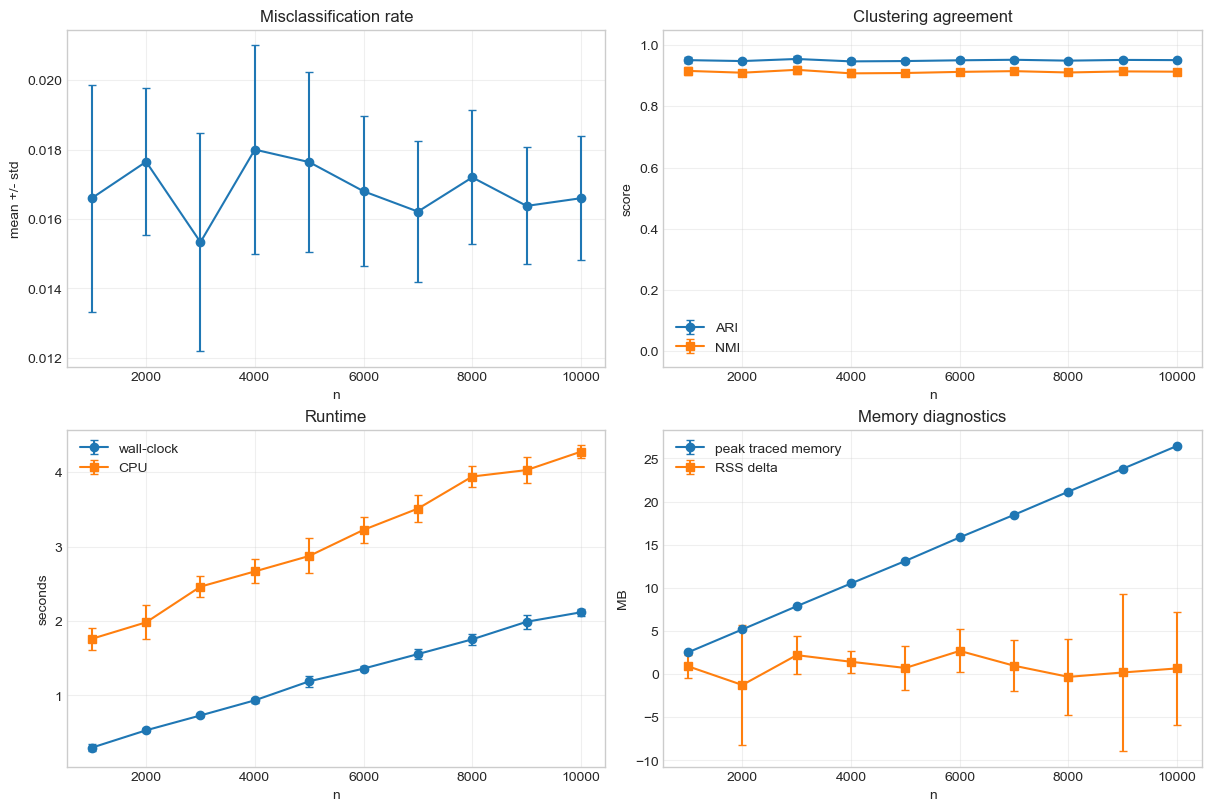

PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_summary.png')

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = summary["n"].to_numpy()

axes[0, 0].errorbar(
    x,
    summary["misclassification_mean"],
    yerr=summary["misclassification_std"].fillna(0.0),
    marker="o",
    capsize=3,
)
axes[0, 0].set_title("Misclassification rate")
axes[0, 0].set_xlabel("n")
axes[0, 0].set_ylabel("mean +/- std")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].errorbar(x, summary["ari_mean"], yerr=summary["ari_std"].fillna(0.0), marker="o", capsize=3, label="ARI")
axes[0, 1].errorbar(x, summary["nmi_mean"], yerr=summary["nmi_std"].fillna(0.0), marker="s", capsize=3, label="NMI")
axes[0, 1].set_title("Clustering agreement")
axes[0, 1].set_xlabel("n")
axes[0, 1].set_ylabel("score")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].errorbar(x, summary["wall_clock_sec_mean"], yerr=summary["wall_clock_sec_std"].fillna(0.0), marker="o", capsize=3, label="wall-clock")
axes[1, 0].errorbar(x, summary["cpu_time_sec_mean"], yerr=summary["cpu_time_sec_std"].fillna(0.0), marker="s", capsize=3, label="CPU")
axes[1, 0].set_title("Runtime")
axes[1, 0].set_xlabel("n")
axes[1, 0].set_ylabel("seconds")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].errorbar(
    x,
    summary["peak_traced_memory_mb_mean"],
    yerr=summary["peak_traced_memory_mb_std"].fillna(0.0),
    marker="o",
    capsize=3,
    label="peak traced memory",
)
if summary["rss_delta_mb_mean"].notna().any():
    axes[1, 1].errorbar(
        x,
        summary["rss_delta_mb_mean"],
        yerr=summary["rss_delta_mb_std"].fillna(0.0),
        marker="s",
        capsize=3,
        label="RSS delta",
    )
axes[1, 1].set_title("Memory diagnostics")
axes[1, 1].set_xlabel("n")
axes[1, 1].set_ylabel("MB")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

fig_path

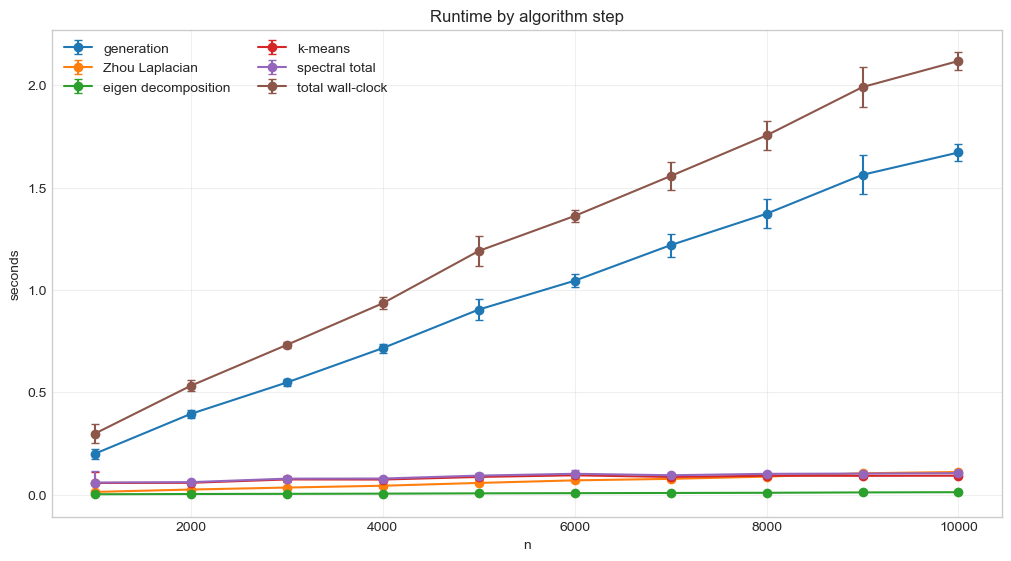

PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian/EXP-20260426-004_uniform_hsbm_n_scaling_zhou_laplacian_runtime_breakdown.png')

In [16]:
x = summary["n"].to_numpy()

runtime_series = [
    ("generation_wall_sec", "generation"),
    ("zhou_laplacian_wall_sec", "Zhou Laplacian"),
    ("eigen_decomposition_wall_sec", "eigen decomposition"),
    ("kmeans_wall_sec", "k-means"),
    ("spectral_clustering_wall_sec", "spectral total"),
    ("wall_clock_sec", "total wall-clock"),
]

fig, ax = plt.subplots(figsize=(10, 5.5), constrained_layout=True)
for col, label in runtime_series:
    mean_col = f"{col}_mean"
    std_col = f"{col}_std"
    if mean_col not in summary.columns:
        continue
    ax.errorbar(
        x,
        summary[mean_col],
        yerr=summary[std_col].fillna(0.0) if std_col in summary.columns else None,
        marker="o",
        capsize=3,
        label=label,
    )

ax.set_title("Runtime by algorithm step")
ax.set_xlabel("n")
ax.set_ylabel("seconds")
ax.grid(alpha=0.3)
ax.legend(ncols=2)

runtime_breakdown_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_runtime_breakdown.png"
fig.savefig(runtime_breakdown_path, dpi=180, bbox_inches="tight")
plt.show()

runtime_breakdown_path

## 더 큰 n을 추가하는 선택 셀

sweep을 확장할 때만 아래 셀을 수정해서 사용한다.


In [17]:
# df_n12000 = run_n_experiment(12000)